# 1. Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 2. Entendiendo el dataset

In [2]:
# Importamos el dataset
url = 'https://raw.githubusercontent.com/ezeperezds/Anemia-Prediction-System/refs/heads/main/data/raw/anemia.csv'

data = pd.read_csv(url)

In [3]:
data.sample(5)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
816,1,13.4,17.7,31.6,97.2,1
398,1,14.7,22.3,28.6,89.5,0
1414,0,13.0,26.2,31.3,74.9,0
1025,0,11.3,18.6,29.5,99.6,1
1197,0,12.9,21.8,31.9,94.4,0


In [4]:
data.shape

(1421, 6)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


## Estructura del dataset

---

Cantidad de filas: 1421

Cantidad de columnas: 6

---

### Variables y tipos de datos:

* 1. Gender: Genero del paciente (0: Masculino ; 1: Femenino); Tipo de dato -> Int
* 2. Hemoglobin: Gramos de hemoglobina por decilitro de sangre (g/dL); Tipo de dato -> Float
* 3. MCH: Masa promedio de hemoglobina dentro de cada glóbulo rojo (pg); Tipo de dato -> Float
* 4. MCHC: Concentración de la hemoglobina dentro de los glóbulos rojos (g/dL); Tipo de dato -> Float
* 5. MCV: Volumen promedio de un glóbulo rojo (fL); Tipo de dato -> Float
* 6. Result: Indica si el paciente tiene o no anemia; Tipo de dato -> Int



# 3. EDA

## Datos nulos

In [6]:
data.isnull().sum()

,0
Gender,0
Hemoglobin,0
MCH,0
MCHC,0
MCV,0
Result,0


In [19]:
data.isna().sum()

,0
Gender,0
Hemoglobin,0
MCH,0
MCHC,0
MCV,0
Result,0
Gender_label,0
Result_label,0


In [18]:
nulos = pd.DataFrame({
    'nulos': data.isnull().sum(),
    'porcentaje': (data.isnull().sum() / len(data)) * 100
    }
                     )

nulos.sort_values('porcentaje', ascending=False)
nulos

,nulos,porcentaje
Gender,0,0.0
Hemoglobin,0,0.0
MCH,0,0.0
MCHC,0,0.0
MCV,0,0.0
Result,0,0.0
Gender_label,0,0.0
Result_label,0,0.0


## Estadistica descriptiva

In [7]:
data.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


In [8]:
data['Gender_label'] = data['Gender'].map({
    0: 'Masculino',
    1: 'Femenino'
    }
                                          )

data['Result_label'] = data['Result'].map({
    0: 'Sin Anemia',
    1: 'Con Anemia'
    }
                                          )

ax = px.histogram(
    data_frame=data,
    x='Gender_label',
    color='Result_label',
    barmode='group',
    title='Distribución de pacientes con Anemia según genero',
    labels={'Gender_label': 'Genero',
            'Result_label': 'Diagnostico'}
    )

ax.show()

## Regla de sturges

k = 1 + 3.322 ⋅ log10(n)

k = 11

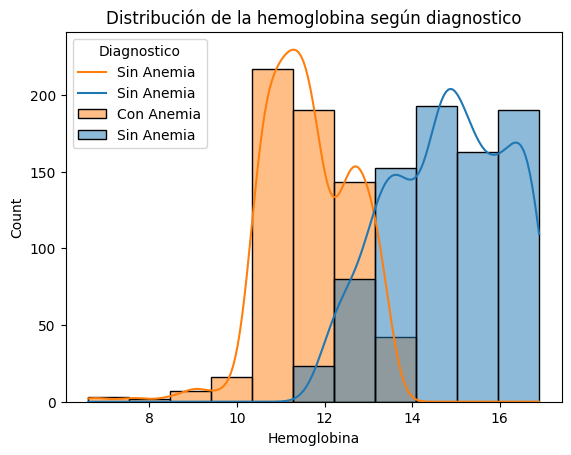

In [37]:
ax = sns.histplot(data=data,
                  x='Hemoglobin',
                  hue='Result_label',
                  bins=11,
                  kde=True)

plt.title('Distribución de la hemoglobina según diagnostico')
plt.xlabel('Hemoglobina')
plt.legend(labels=data['Result_label'], title='Diagnostico')
plt.show()

In [9]:
ax = px.box(data_frame=data,
            x='Hemoglobin',
            color='Result_label',
            title='',
            labels={'Hemoglobin': 'Hemoglobina',
                    'Result_label': 'Diagnostico'})
ax.show()

## Correlacion entre variables

In [10]:
data.corr(numeric_only=True)

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
Gender,1.000000,0.010972,0.001042,0.014574,-0.040447,0.253169
Hemoglobin,0.010972,1.000000,0.014081,-0.042597,-0.025885,-0.796261
MCH,0.001042,0.014081,1.000000,0.018795,-0.015948,-0.028678
MCHC,0.014574,-0.042597,0.018795,1.000000,0.068450,0.048067
MCV,-0.040447,-0.025885,-0.015948,0.068450,1.000000,-0.020571
Result,0.253169,-0.796261,-0.028678,0.048067,-0.020571,1.000000


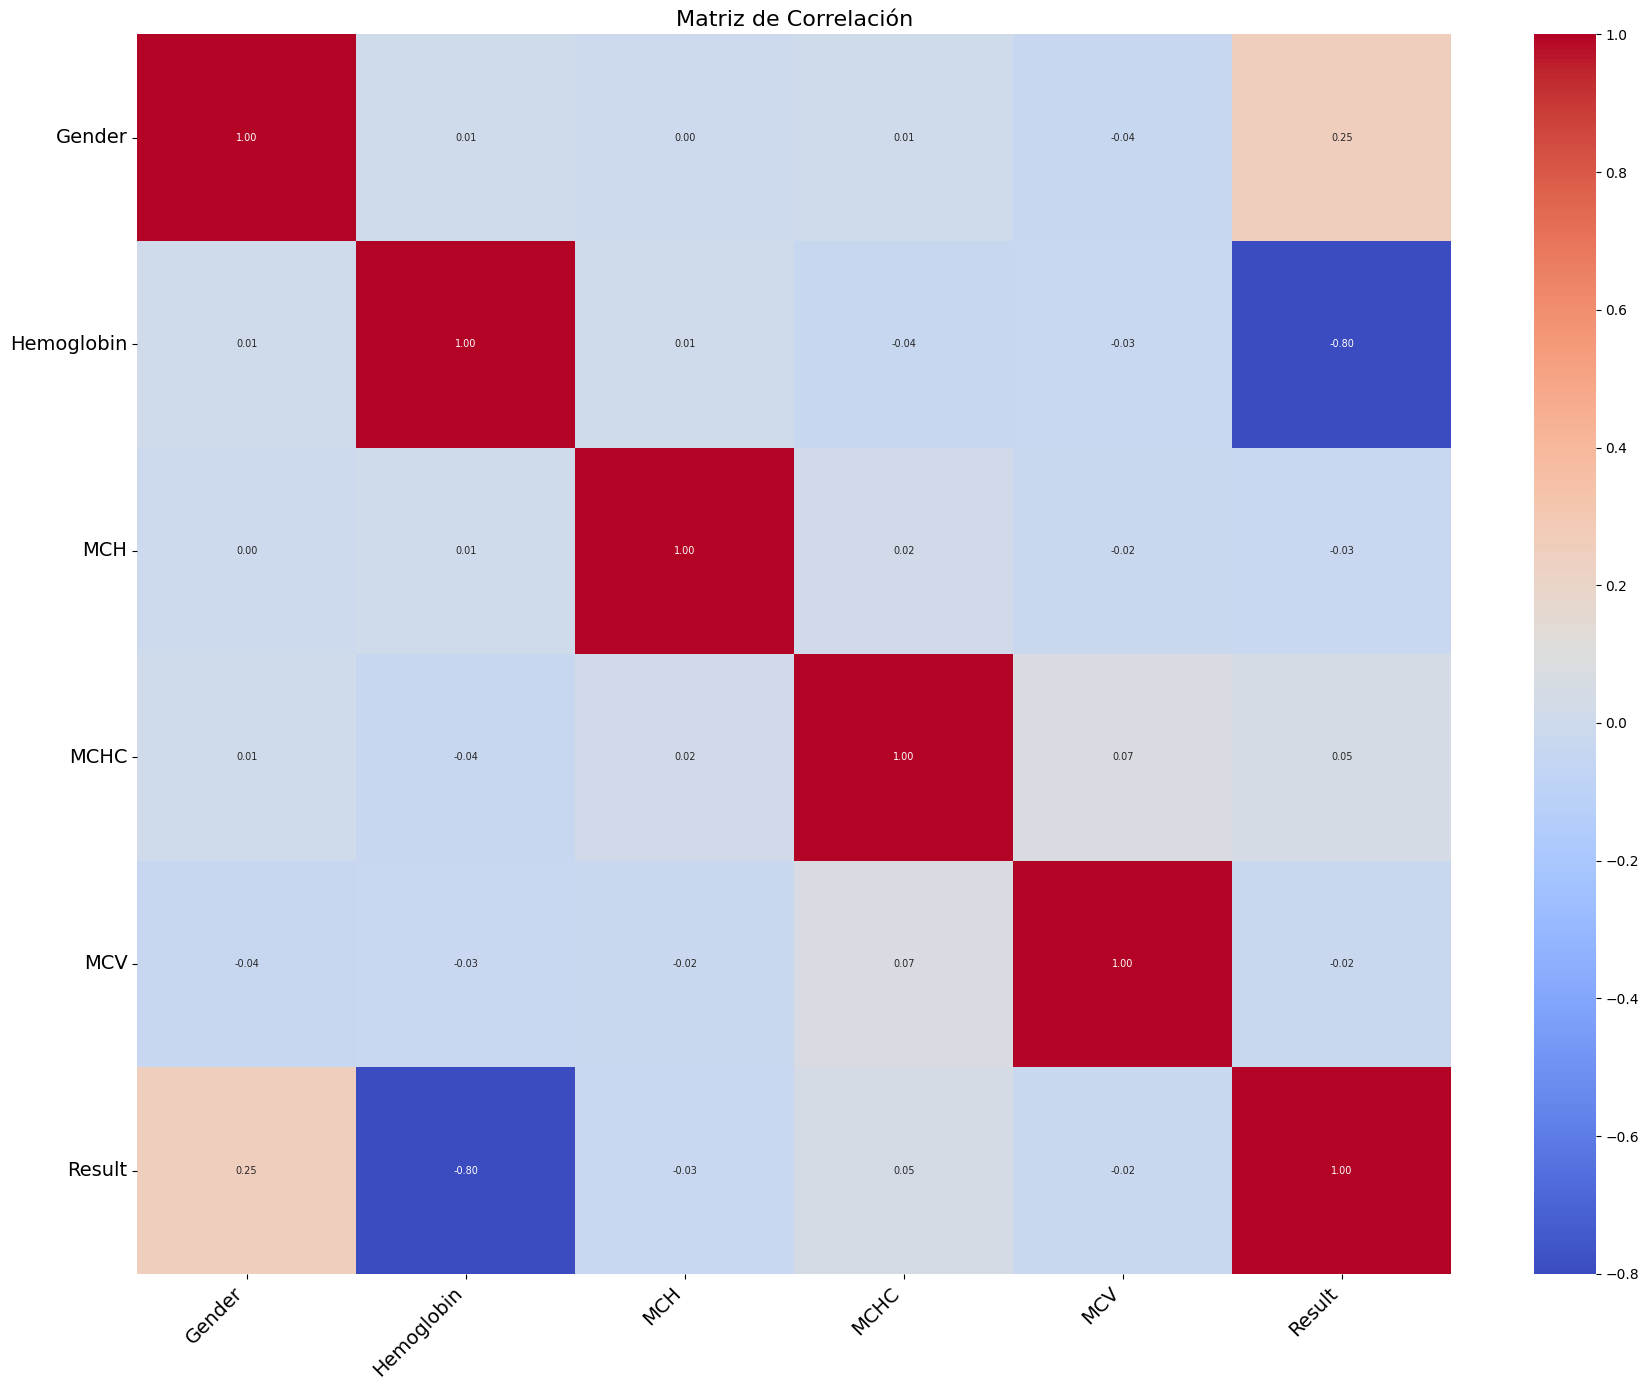

In [11]:
df_corr = data.corr(numeric_only=True).round(2)

plt.figure(figsize=(18, 14))
sns.heatmap(df_corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            annot_kws={'size': 7}
            )

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=360, fontsize=14)
plt.title("Matriz de Correlación", fontsize=16)
plt.tight_layout()
plt.show()

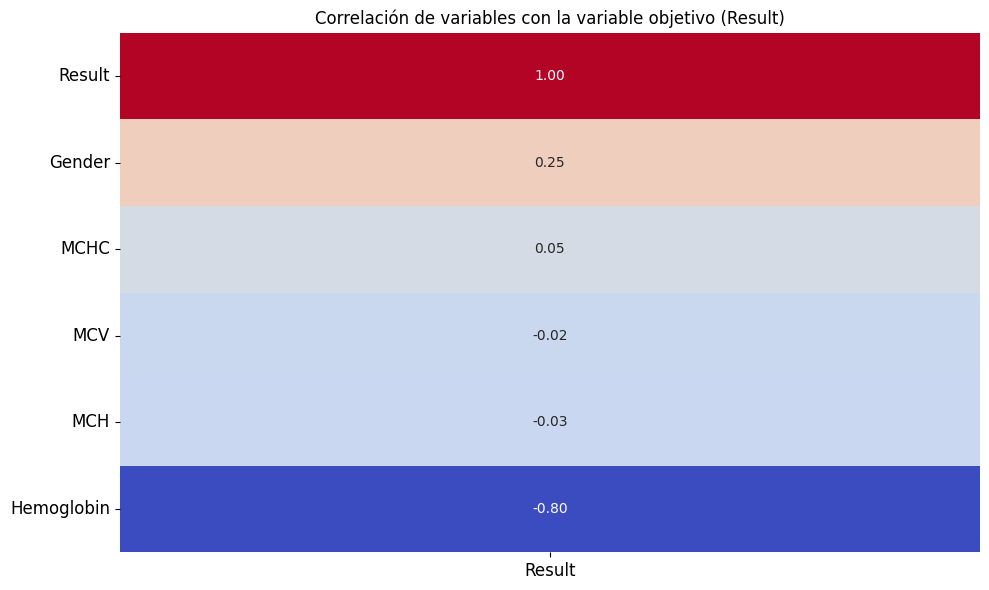

In [12]:
plt.figure(figsize=(10, 6))

sns.heatmap(df_corr[['Result']].sort_values(by='Result', ascending=False),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=False
            )

plt.title("Correlación de variables con la variable objetivo (Result)")
plt.yticks(rotation=360, fontsize=12)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

## Datos duplicados

In [13]:
data.duplicated().sum()

np.int64(887)

In [14]:
data.duplicated().mean() * 100

np.float64(62.42083040112597)

In [15]:
data.value_counts().reset_index(name="frecuencia")

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Gender_label,Result_label,frecuencia
0,1,16.9,24.2,32.1,92.5,0,Femenino,Sin Anemia,3
1,1,16.8,24.3,30.5,90.7,0,Femenino,Sin Anemia,3
2,1,16.8,22.7,32.0,94.3,0,Femenino,Sin Anemia,3
3,1,16.5,19.3,29.2,69.7,0,Femenino,Sin Anemia,3
4,1,16.4,27.4,31.9,100.2,0,Femenino,Sin Anemia,3
...,...,...,...,...,...,...,...,...,...
529,0,11.0,19.5,31.7,77.1,1,Masculino,Con Anemia,1
530,0,10.5,25.5,29.6,83.2,1,Masculino,Con Anemia,1
531,0,7.5,28.8,30.8,86.4,1,Masculino,Con Anemia,1
532,0,6.9,28.1,32.5,94.6,1,Masculino,Con Anemia,1


In [16]:
print("Duplicados exactos:", data.duplicated().sum())

data.value_counts().reset_index(name="frecuencia").head(20)

Duplicados exactos: 887


,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Gender_label,Result_label,frecuencia
0,1,16.9,24.2,32.1,92.5,0,Femenino,Sin Anemia,3
1,1,16.8,24.3,30.5,90.7,0,Femenino,Sin Anemia,3
2,1,16.8,22.7,32.0,94.3,0,Femenino,Sin Anemia,3
3,1,16.5,19.3,29.2,69.7,0,Femenino,Sin Anemia,3
4,1,16.4,27.4,31.9,100.2,0,Femenino,Sin Anemia,3
5,1,16.4,18.7,29.6,96.4,0,Femenino,Sin Anemia,3
6,1,16.3,26.7,29.9,84.1,0,Femenino,Sin Anemia,3
7,1,16.3,24.8,30.6,83.9,0,Femenino,Sin Anemia,3
8,1,16.2,19.5,31.0,76.6,0,Femenino,Sin Anemia,3
9,1,16.2,17.9,27.8,74.3,0,Femenino,Sin Anemia,3


## Distribución de la variable objetivo

In [17]:
data.Result.value_counts(normalize=True)

,proportion
Result,
0,0.563688
1,0.436312


# 4. Informe

---